# Main-paper exhibits — Tables 1–5, Figures 1–2

Every number in the manuscript's exhibits is regenerated or verified from the aggregate artifacts in `artifacts/`; no licensed microdata is used or required (see `DATA_ACCESS.md`).
Outputs are stored, so the notebooks render on GitHub without running. Rebuild with `python3 code/make_notebooks.py`.


## Setup


In [ ]:
import sys, runpy
sys.path.insert(0, "code"); import exhibits_lib as X
md = open("manuscript/PE_Labour_Adjustment_manuscript_2026-08-31.md", encoding="utf-8").read()
paper, appendix = X.split_document(md)
pool = X.load_pool("artifacts")
print("artifact pool loaded ·", len(pool), "quantized values")


artifact pool loaded · 58026 quantized values


## Figure 1 — hiring responses across pre-deal hiring states
Built from `I70.json`: the 286 event-level pairs, fixed quintile-bin means, the primary gradient with an event-bootstrap band, and the **actual** 2,000 pseudo-sample gradients.


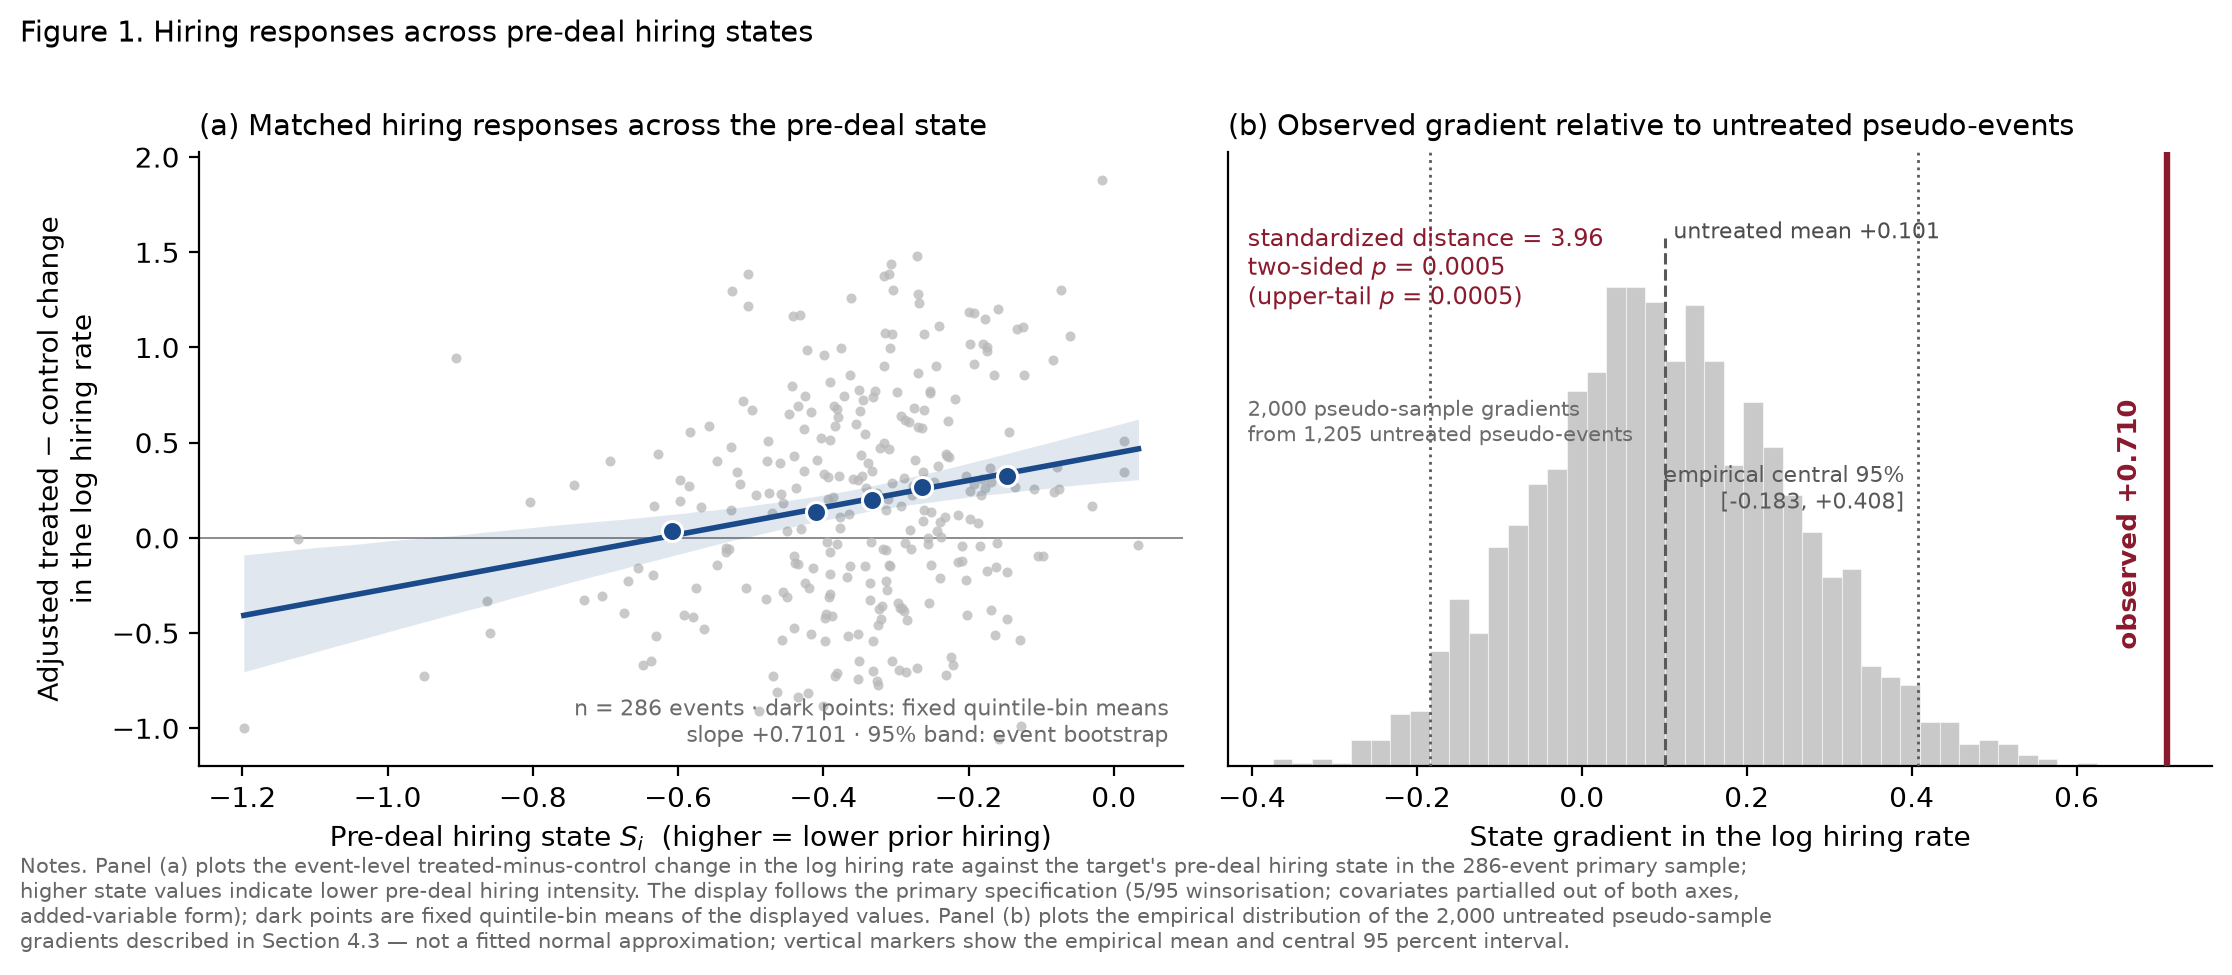

saved figure1_state_gradient.png/.pdf


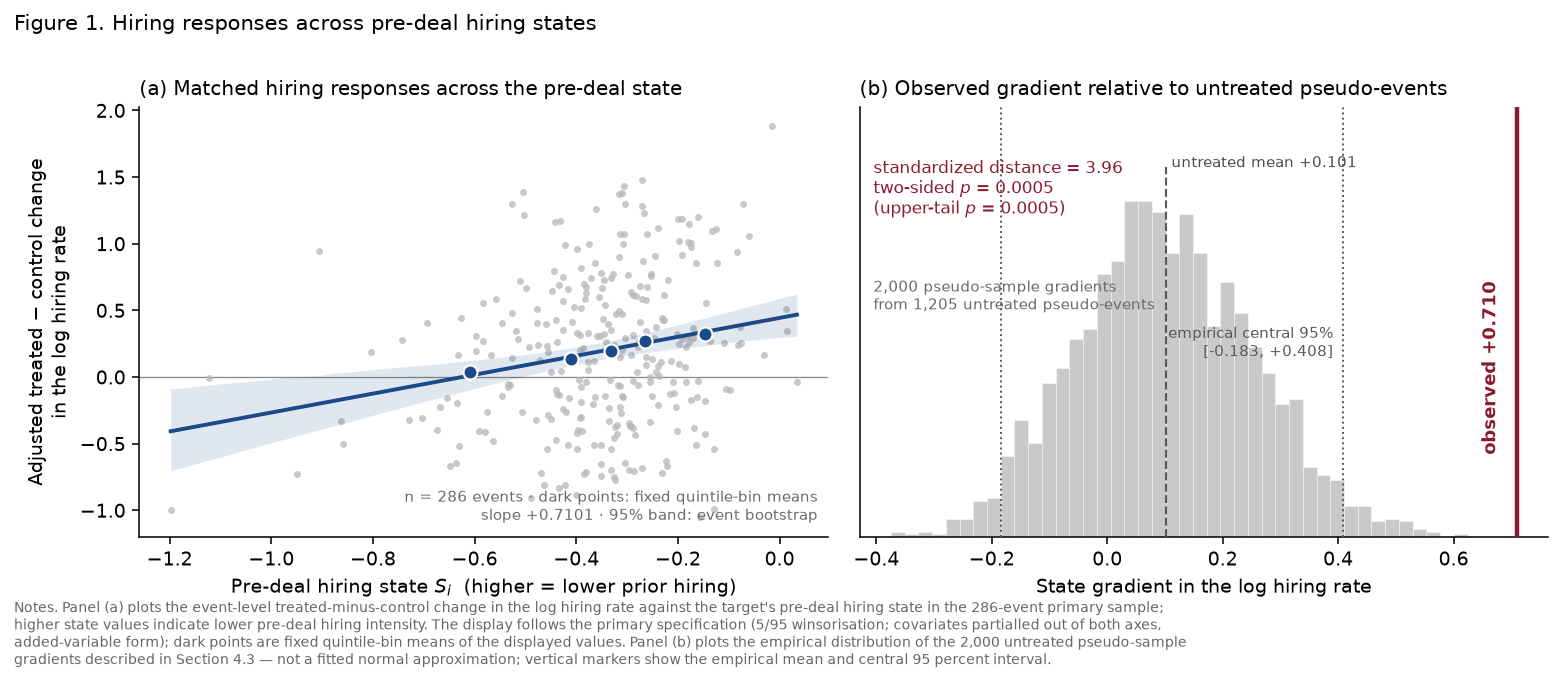

In [ ]:
runpy.run_path("code/build_figure1.py", run_name="__main__")
_figs = [open("figures/figure1_state_gradient.png", "rb").read()]


## Figure 2 — quarterly hiring differences relative to matched controls


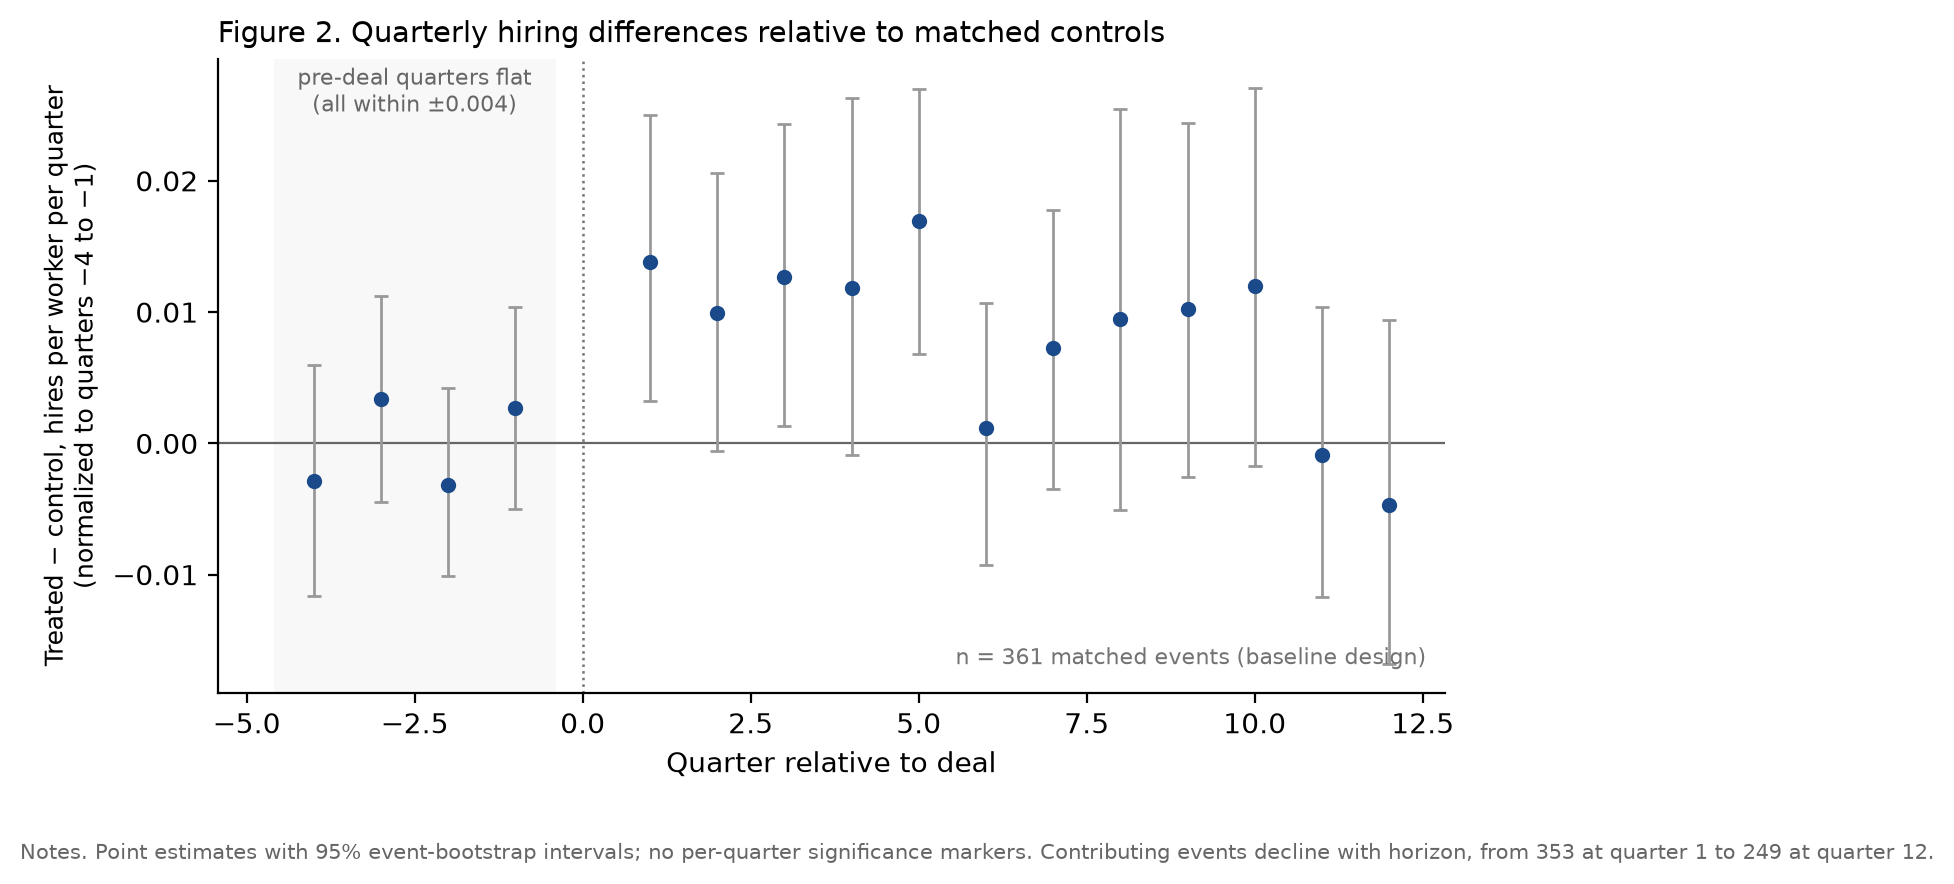

saved figure2_quarterly.png/.pdf


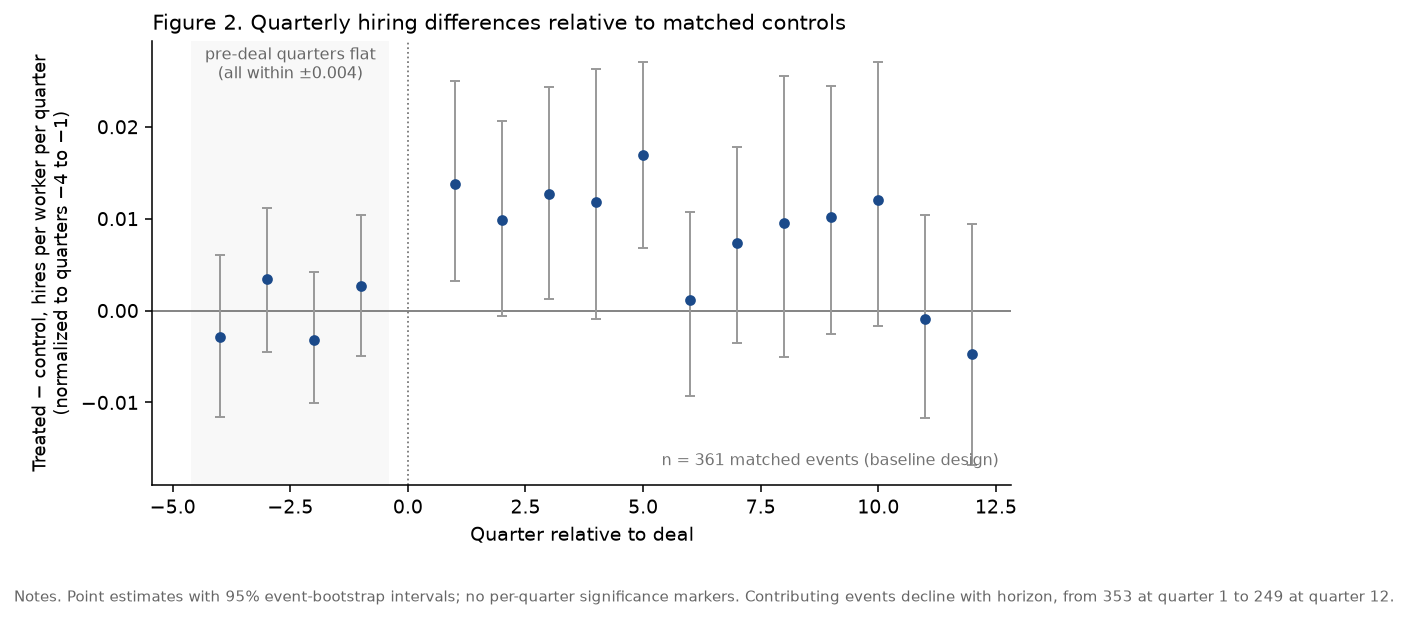

In [ ]:
runpy.run_path("code/build_figure2.py", run_name="__main__")
_figs = [open("figures/figure2_quarterly.png", "rb").read()]


## Main-text tables — displayed and verified
Each table is shown exactly as printed in the manuscript; the check confirms every decimal token exists in the generating artifacts at the displayed precision.


In [ ]:
tabs = X.extract_tables(paper)
bad = 0
for title, block in tabs:
    n, un = X.verify_block(block, pool)
    print(f"{title[:74]:<76} tokens {n:>3} · unmatched {len(un)}")
    if un: bad += len(un); print("   →", un[:6])
assert bad == 0
print(f"\nTOTAL: {len(tabs)} main-text tables verified")


Table 1. Sample construction and characteristics of the matched population   tokens  21 · unmatched 0
Table 2. Average post-investment changes relative to matched controls        tokens   9 · unmatched 0
Table 3. Hiring responses across pre-deal hiring states                      tokens  18 · unmatched 0
Table 4. Worker-flow and employment gradients across pre-deal hiring state   tokens  31 · unmatched 0
Table 5. Pre-deal diagnostics for the hiring-state gradient                  tokens   9 · unmatched 0

TOTAL: 5 main-text tables verified


### Table


In [ ]:
if 0 < len(tabs):
    title, block = tabs[0]
    _md = "### " + title + "\n\n" + block
    print(title)
else:
    _md = ""


### Table 1. Sample construction and characteristics of the matched population

**Panel A. Sample construction**

|  | Events |
|---|---:|
| Private equity investment events identified | 752 |
| &nbsp;&nbsp;Unable to link to NPS records | −168 |
| &nbsp;&nbsp;Insufficient pre-investment history | −120 |
| &nbsp;&nbsp;Fewer than five insured employees at transaction | −75 |
| &nbsp;&nbsp;No eligible baseline control cell | −10 |
| **Baseline matched universe** | **379** |
| Average-effect sample ($\geq 6$ observed months per window, target and a control) | 367 |
| Conventional heterogeneity matching, without state balance | 301 |
| **Primary state-balanced gradient sample** | **286** |
| &nbsp;&nbsp;&nbsp;&nbsp;State window, months $-24$ to $-13$, not fully observed | −53 |
| &nbsp;&nbsp;&nbsp;&nbsp;Employment below five within the state window | −1 |
| &nbsp;&nbsp;&nbsp;&nbsp;No state-balanced control cell | −17 |
| &nbsp;&nbsp;&nbsp;&nbsp;No usable primary log-hiring outcome | −22 |
| Complete transaction-characteristic sample | 180 |
| Audited financial-statement sample used in the one-year analysis | 147 |

**Panel B. Target characteristics and sample scope**

| Characteristic | Matched targets | Identified targets not entering the matched design |
|---|---:|---:|
| Median insured employment | 79.8 | 135.6 |
| Mean insured employment | 218.2 | - |
| Median deal year | 2021 | - |
| Two-digit industries represented | 44 | - |

**Panel C. Covariate and state balance in the primary 286-event sample**

| Variable | Treated | State-balanced controls | Normalised difference |
|---|---:|---:|---:|
| Log insured employment | 4.4418 | 4.3795 | +0.0538 |
| Pre-deal employment growth | +0.0954 | +0.0795 | +0.0651 |
| Firm age, years | 16.5236 | 18.0995 | −0.1676 |
| Pre-deal hiring state $S$ | −0.3517 | −0.3431 | −0.0390 |
| Prior hiring rate, 12 months | 0.4362 | 0.4155 | +0.0624 |
| Prior separation rate, 12 months | 0.3521 | 0.3500 | +0.0075 |

*Notes.* The 367-event average-effect sample and the 286-event primary gradient sample are parallel branches of the 379-event baseline universe rather than successive restrictions. The indented rows below the primary state-balanced sample account for the 93 events excluded from that branch. The 301-event conventional heterogeneity sample is generated without imposing state balance. Panel C is calculated on the 286-event primary sample against its state-balanced controls. The normalised difference is
$$
\frac{\bar X_T-\bar X_C}
{\sqrt{(s_T^2+s_C^2)/2}}.
$$
Prior hiring and separation rates refer to the twelve-month pre-investment outcome window.


Table 1. Sample construction and characteristics of the matched population


### Table


In [ ]:
if 1 < len(tabs):
    title, block = tabs[1]
    _md = "### " + title + "\n\n" + block
    print(title)
else:
    _md = ""


### Table 2. Average post-investment changes relative to matched controls

| Outcome | Matched change | 95% CI | Events |
|---|---:|---:|---:|
| Log employment at +12 months | 0.0878 | [0.0462, 0.1300] | 367 |
| Hiring rate, post 12 months - pre 12 months | 0.0485 | [0.0163, 0.0814] | 367 |
| Separation rate, post 12 months - pre 12 months | 0.0007 | [−0.0353, 0.0398] | 367 |

*Notes.* Employment is measured at month $+12$ relative to mean employment over months $-12$ through $-1$, and then differenced against matched controls. Hiring and separation rates are twelve-month sums of worker flows divided by mean insured employment over the corresponding window; reported coefficients are treated-minus-control changes from the pre- to the post-investment window. The average-effect sample requires at least six observed months in each required window for the target and an eligible control and is distinct from the 286-event primary state-gradient sample.


Table 2. Average post-investment changes relative to matched controls


### Table


In [ ]:
if 2 < len(tabs):
    title, block = tabs[2]
    _md = "### " + title + "\n\n" + block
    print(title)
else:
    _md = ""


### Table 3. Hiring responses across pre-deal hiring states

**Panel A. Primary state gradient**

| Quantity | Estimate |
|---|---:|
| State gradient | 0.7101 [0.3187, 1.1254] |
| Effect of an interquartile move | 0.2005 [0.0900, 0.3177] |
| Untreated reference mean (SD) | 0.1010 (0.1538) |
| Excess over untreated mean | 0.6091 |
| Standardized distance | 3.96 |
| Empirical two-sided $p$ | 0.0005 |

**Panel B. Effect of balancing the pre-deal hiring state**  
*Preferred 5/95-winsorised specification, common 286-event sample*

| Matching design | Matched gradient |
|---|---:|
| Conventional matching, state not balanced | 0.4698 |
| State-balanced matching | 0.7101 |

**Panel C. Control-path diagnostic**  
*Unwinsorised decomposition, common 286-event sample*

| Component slope | Conventional | State-balanced |
|---|---:|---:|
| Treated-side slope | 0.8425 | 0.8425 |
| Control-side slope with respect to treated state | 0.2950 | 0.0056 |

*Notes.* Panel A reports the primary 5/95-winsorised specification. The confidence interval is obtained from 2,000 treated-event bootstrap draws. The untreated reference distribution is based on 2,000 gradients drawn from the pool of 1,205 untreated pseudo-events and processed using the corresponding primary procedure. The empirical two-sided $p$-value follows the centred empirical rule described in Section 4.3. Panel B compares matching procedures on the same 286 treated events. Panel C uses an unwinsorised outcome and is a control-path diagnostic; its component differences therefore do not numerically equal the winsorised gradients in Panel B.


Table 3. Hiring responses across pre-deal hiring states


### Table


In [ ]:
if 3 < len(tabs):
    title, block = tabs[3]
    _md = "### " + title + "\n\n" + block
    print(title)
else:
    _md = ""


### Table 4. Worker-flow and employment gradients across pre-deal hiring states

**Panel A. Worker-inflow measures**

| Outcome | Gradient | Untreated reference mean | Empirical two-sided $p$ | Events |
|---|---:|---:|---:|---:|
| Log hiring rate | 0.7101 | 0.1006 | 0.0005 | 286 |
| Log worker-entry count | 0.6315 | 0.1858 | 0.0110 | 286 |
| Log worker-entry count, controlling for $\Delta$ log employment | 0.6957 | 0.0377 | 0.0005 | 286 |

**Panel B. Worker flows and employment**

| Outcome | Gradient | Standardized distance | Empirical two-sided $p$ | Events |
|---|---:|---:|---:|---:|
| Log churn rate | 0.3816 | 3.08 | 0.0020 | 288 |
| Log separation rate | 0.1788 | 1.17 | 0.2384 | 281 |
| Log employment | −0.0580 | −2.60 | 0.0050 | 289 |

**Panel C. Within-event outcome contrasts**

| Contrast | Estimate | Reference mean / standardized distance | Empirical two-sided $p$ | Events |
|---|---:|---:|---:|---:|
| Hiring - employment | 0.7536 | 0.0232 / 4.56 | 0.0010 | 286 |
| Churn - employment | 0.4539 | −0.0750 / 4.19 | 0.0010 | 288 |

*Notes.* The state definition, matching structure, covariate adjustment, and untreated-reference construction follow Sections 4.1-4.3. Panel A fixes the primary 286-event design and changes only the worker-inflow outcome; each untreated reference mean is re-estimated for the corresponding outcome under the same run. The employment-change control in the third row is post-treatment and is used only as a denominator diagnostic. Panel B uses outcome-specific eligible samples because the corresponding windows must be non-degenerate. Churn is worker entries plus separations divided by employment. Panel C constructs each contrast within the same events rather than comparing separately estimated levels of statistical significance. Standardized distance is the observed estimate minus its untreated reference mean divided by the reference-distribution standard deviation. The reference distributions in this table come from the outcome-specific run, whose pseudo-event pool contains 1,246 events; the primary pool used in Section 4.3, Table 3, and Figure 1 contains 1,205. The two implementations differ only in whether pseudo-events without a defined log-hiring outcome are retained in the pool, which is why the hiring-rate reference moments differ in the third decimal (0.1006 versus 0.1010).


Table 4. Worker-flow and employment gradients across pre-deal hiring states


### Table


In [ ]:
if 4 < len(tabs):
    title, block = tabs[4]
    _md = "### " + title + "\n\n" + block
    print(title)
else:
    _md = ""


### Table 5. Pre-deal diagnostics for the hiring-state gradient

| Diagnostic | Estimate | 95% CI | Events |
|---|---:|---:|---:|
| Pre-deal excess gradient, non-overlapping earlier state | −0.1770 | [−0.4394, 0.0854] | 250 |
| Pre-deal gradient, primary-state specification | 0.1068 | [−0.1955, 0.4351] | 283 |
| Post-deal gradient, same events | 0.7250 | [0.3259, 1.1081] | 283 |

*Notes.* The first row avoids overlap between the state and the earlier outcome by moving the state window from months $-24$ through $-13$ to months $-36$ through $-25$. This produces a mechanically cleaner comparison but changes the moderator relative to the primary specification. The second row retains the primary state definition but shares observations between the state and the earlier outcome. The third row reports the post-investment gradient on the same 283 events as the second row. These specifications are complementary diagnostics rather than formal tests of the identifying assumption. Relative-magnitude sensitivity calculations are reported in Online Appendix D.


Table 5. Pre-deal diagnostics for the hiring-state gradient


### Table


In [ ]:
if 5 < len(tabs):
    title, block = tabs[5]
    _md = "### " + title + "\n\n" + block
    print(title)
else:
    _md = ""
